<a href="https://colab.research.google.com/github/Abrar-404/AI-ML_Practices_and_Assignments/blob/main/Module_08_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 8: Scaling — Practice Problems

এই notebook-এ real datasets ব্যবহার করে scaling-এর সব concepts practice করা হবে।

**Datasets used:**
- California Housing Dataset
- Diabetes Dataset
- Breast Cancer Dataset
- Wine Dataset

সব dataset sklearn থেকে directly load করা যাবে — কোনো external file লাগবে না।

---
## Setup — Run this first

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing, load_diabetes, load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer

print('Setup complete!')

Setup complete!


---
# Part 1: Why Scaling Matters
**Dataset: California Housing**

### Problem 1
California Housing dataset load করো এবং একটি DataFrame বানাও।
প্রতিটি feature-এর min, max এবং mean print করো।
দেখো feature-গুলোর range কতটা আলাদা।

In [ ]:
# Load dataset
housing = fetch_california_housing()
df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)

# Your code here: print min, max, mean of each feature
summary = pd.DataFrame({
    'Min':  df_housing.min(),
    'Max':  df_housing.max(),
    'Mean': df_housing.mean().round(2),
    'Range': (df_housing.max() - df_housing.min()).round(2)  # bonus: range column
})

print(summary)

                   Min           Max     Mean     Range
MedInc        0.499900     15.000100     3.87     14.50
HouseAge      1.000000     52.000000    28.64     51.00
AveRooms      0.846154    141.909091     5.43    141.06
AveBedrms     0.333333     34.066667     1.10     33.73
Population    3.000000  35682.000000  1425.48  35679.00
AveOccup      0.692308   1243.333333     3.07   1242.64
Latitude     32.540000     41.950000    35.63      9.41
Longitude  -124.350000   -114.310000  -119.57     10.04


### Problem 2
California Housing dataset-এর সব features-এর distribution একসাথে plot করো (histogram)।
কোন features-এর range সবচেয়ে বড়? কোনটা সবচেয়ে ছোট? চিহ্নিত করো।

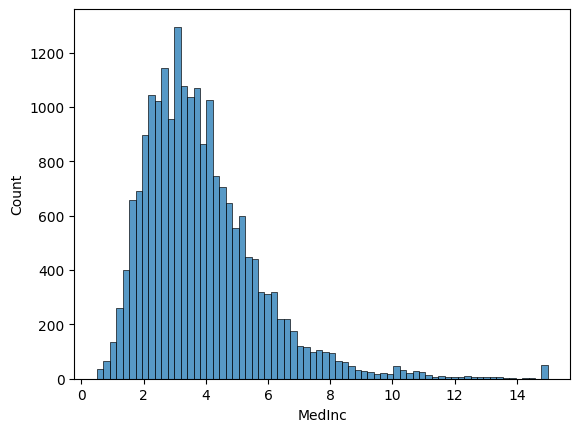

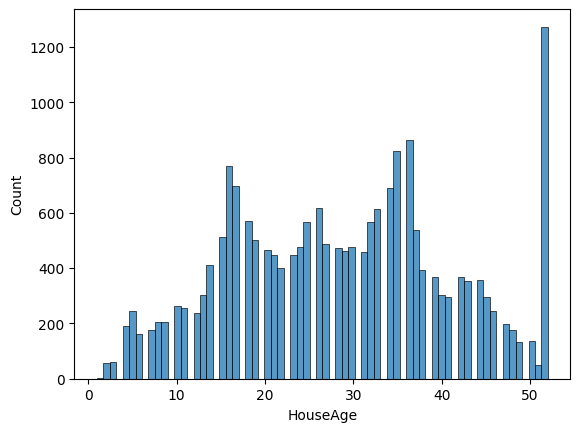

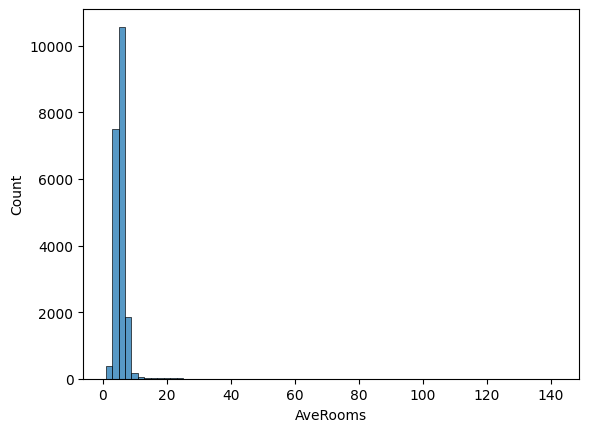

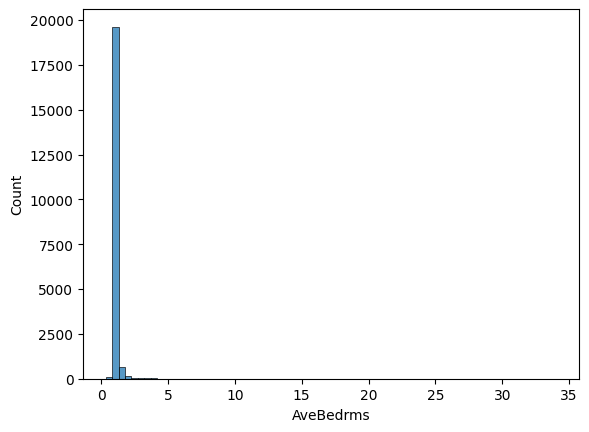

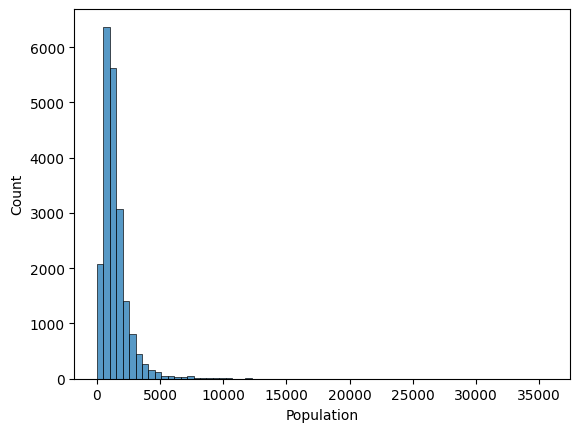

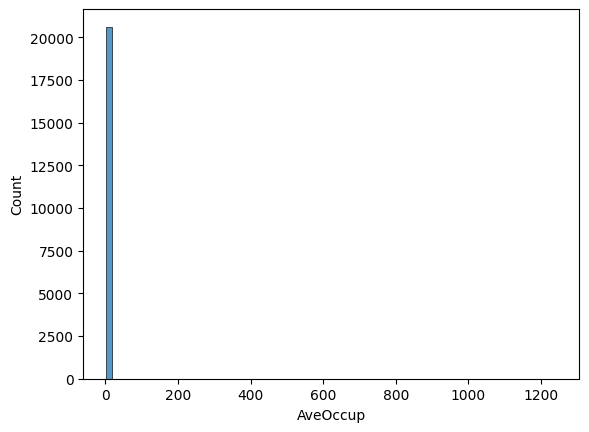

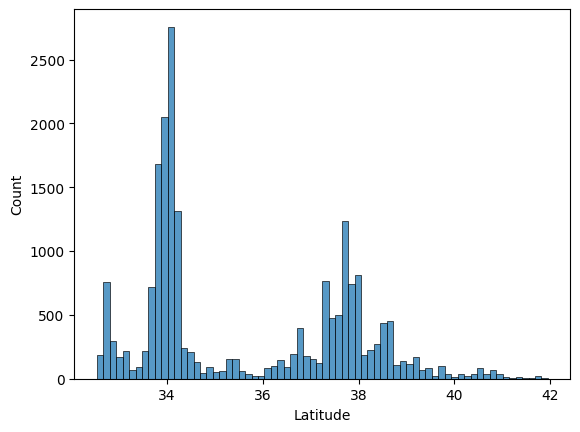

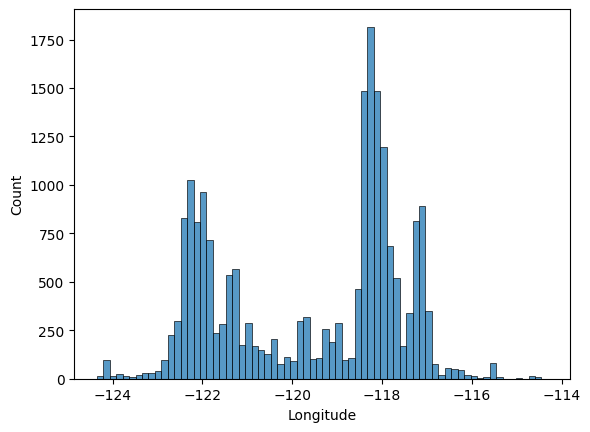

Largest Range: Population (35679.00)
Smallest Range: Latitude (9.41)


In [ ]:
# Your code here: plot histogram for all features
# Load dataset
housing = fetch_california_housing()
df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)

for cols in df_housing.columns:
  sns.histplot(df_housing[cols], bins = 70)
  plt.show()

ranges = df_housing.max() - df_housing.min()
print(f'Largest Range: {ranges.idxmax()} ({ranges.max():.2f})')
print(f'Smallest Range: {ranges.idxmin()} ({ranges.min():.2f})')

### Problem 3
Diabetes dataset load করো। Features-এর scale দেখে বলো —
scaling ছাড়া কোন ধরনের ML model সবচেয়ে বেশি সমস্যায় পড়বে এবং কেন?
(KNN, Decision Tree — এই তিনটির মধ্যে তুলনা করো।)

In [ ]:
# Load diabetes dataset
diabetes = load_diabetes()
df_diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Your code here: explore and answer
print(df_diabetes.describe().round(3))

# Ans:
# 1. KNN: It suffers most because it calculates the result based on the distances between points. Suppose there are two features, Age and Salary. If Age is 25 and Salary is 100000, the salary will dominate the data.
# 2. Decision Tree: It doesn't affect much because it only asks if the given value is greater than the threshold with the model is being trained. So in splitting the actual scale between values doesn't matter.

           age      sex      bmi       bp       s1       s2       s3       s4  \
count  442.000  442.000  442.000  442.000  442.000  442.000  442.000  442.000   
mean    -0.000    0.000   -0.000   -0.000   -0.000    0.000   -0.000   -0.000   
std      0.048    0.048    0.048    0.048    0.048    0.048    0.048    0.048   
min     -0.107   -0.045   -0.090   -0.112   -0.127   -0.116   -0.102   -0.076   
25%     -0.037   -0.045   -0.034   -0.037   -0.034   -0.030   -0.035   -0.039   
50%      0.005   -0.045   -0.007   -0.006   -0.004   -0.004   -0.007   -0.003   
75%      0.038    0.051    0.031    0.036    0.028    0.030    0.029    0.034   
max      0.111    0.051    0.171    0.132    0.154    0.199    0.181    0.185   

            s5       s6  
count  442.000  442.000  
mean     0.000    0.000  
std      0.048    0.048  
min     -0.126   -0.138  
25%     -0.033   -0.033  
50%     -0.002   -0.001  
75%      0.032    0.028  
max      0.134    0.136  


---
# Part 2: Standard Scaling
**Dataset: Breast Cancer**

### Problem 4
Breast Cancer dataset load করো এবং train-test split করো (test_size=0.2, random_state=42)।
এরপর StandardScaler দিয়ে শুধু training data-তে fit করো এবং দুটোতেই transform করো।

In [ ]:
# Load dataset
cancer = load_breast_cancer()
df_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
X_cancer = cancer.data
y_cancer = cancer.target

# Your code here: train-test split, fit StandardScaler on train, transform both
X_train, X_test, y_train, y_test = train_test_split(X_cancer, y_cancer, test_size=0.2, random_state=42)

ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)

### Problem 5
Problem 4-এর scaled training data-র mean এবং standard deviation print করো।
Expected output: mean ≈ 0, std ≈ 1।
যদি এই output না পাও, কোথায় ভুল হয়েছে খুঁজে বের করো।

In [ ]:
# Your code here: verify mean and std after scaling
X_train_scaled_mean = round(X_train_scaled.mean(), 5)
X_train_scaled_std = round(X_train_scaled.std(), 5)

print('Mean: \n', X_train_scaled_mean, '\n')
print('Std: \n', X_train_scaled_std)

Mean: 
 -0.0 

Std: 
 1.0


### Problem 6
Breast Cancer dataset-এর যেকোনো একটি feature নিয়ে scaling-এর আগে এবং পরে
KDE plot পাশাপাশি (subplot) দেখাও।
Shape কি একই থাকে নাকি বদলে যায়?

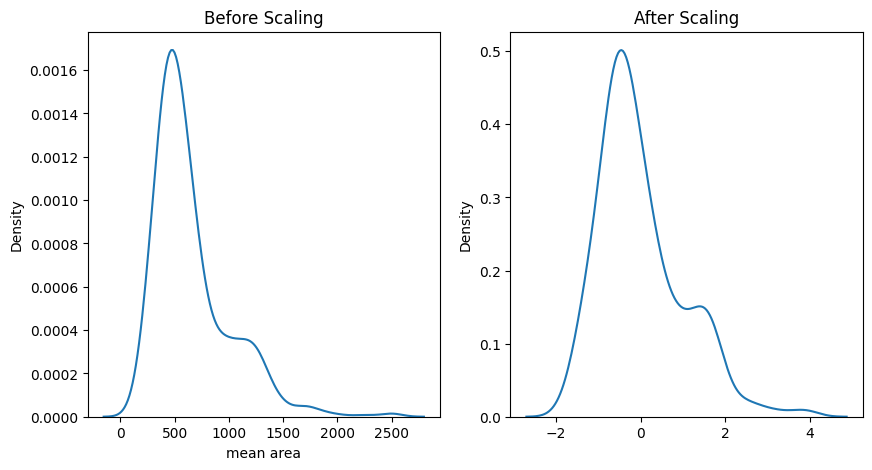

In [67]:
# Your code here: before vs after KDE plot side by side

fig, axes = plt.subplots(1, 2, figsize = (10, 5))

sns.kdeplot(df_cancer['mean area'], ax = axes[0]).set_title('Before Scaling')
sns.kdeplot(X_train_scaled[:, 2], ax = axes[1]).set_title('After Scaling')
plt.show()

# Ans: The shape remains the same but the value of X axis is slightly changed

### Problem 7
StandardScaler manually implement করো — sklearn ব্যবহার না করে।
formula: z = (x - mean) / std
Diabetes dataset-এর 'bmi' column-এ apply করো এবং sklearn-এর output-এর সাথে মিলিয়ে দেখো।

In [73]:
# Your code here: manual StandardScaler and compare with sklearn
diab_mean = df_diabetes['bmi'].mean()
diab_std = df_diabetes['bmi'].std()
manual_scaled = (df_diabetes['bmi'] - diab_mean) / diab_std

ss = StandardScaler()
sklearn_scaled = ss.fit_transform(df_diabetes[['bmi']]).ravel()

difference = np.abs(round((manual_scaled - sklearn_scaled).max(), 2))
print('Difference:', difference)

Difference: 0.0


---
# Part 3: MinMax Scaling
**Dataset: Wine**

### Problem 8
Wine dataset load করো। MinMaxScaler apply করো সব features-এ।
Scaled data-র min এবং max verify করো — সব feature-এ min=0 এবং max=1 হওয়া উচিত।

In [89]:
# Load dataset
wine = load_wine()
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)

# Your code here: apply MinMaxScaler and verify min/max
mms = MinMaxScaler()
df_wine_new = mms.fit_transform(df_wine)
df_wine_scaled = pd.DataFrame(df_wine_new, columns = wine.feature_names)

print(df_wine_scaled.min())
print()
print()
print(df_wine_scaled.max())

alcohol                         0.0
malic_acid                      0.0
ash                             0.0
alcalinity_of_ash               0.0
magnesium                       0.0
total_phenols                   0.0
flavanoids                      0.0
nonflavanoid_phenols            0.0
proanthocyanins                 0.0
color_intensity                 0.0
hue                             0.0
od280/od315_of_diluted_wines    0.0
proline                         0.0
dtype: float64


alcohol                         1.0
malic_acid                      1.0
ash                             1.0
alcalinity_of_ash               1.0
magnesium                       1.0
total_phenols                   1.0
flavanoids                      1.0
nonflavanoid_phenols            1.0
proanthocyanins                 1.0
color_intensity                 1.0
hue                             1.0
od280/od315_of_diluted_wines    1.0
proline                         1.0
dtype: float64


### Problem 9
MinMaxScaler manually implement করো — sklearn ব্যবহার না করে।
formula: x_scaled = (x - min) / (max - min)
Wine dataset-এর 'alcohol' column-এ apply করো এবং sklearn output-এর সাথে তুলনা করো।

In [100]:
# Your code here: manual MinMaxScaler and compare with sklearn
wine_min = df_wine['alcohol'].min()
wine_max = df_wine['alcohol'].max()

wine_scaled_manual = (df_wine['alcohol'] - wine_min) / (wine_max - wine_min)

mms = MinMaxScaler()
wine_scaled_sklearn = mms.fit_transform(df_wine[['alcohol']]).ravel()

wine_diff = round(((wine_scaled_manual - wine_scaled_sklearn).max()), 2)
print('Difference:', wine_diff)

Difference: 0.0


### Problem 10
Wine dataset-এ একটি artificial outlier যোগ করো (যেমন: alcohol = 500)।
MinMaxScaler apply করার পর দেখো বাকি সব values কীভাবে প্রভাবিত হয়।
Before এবং after plot করো।

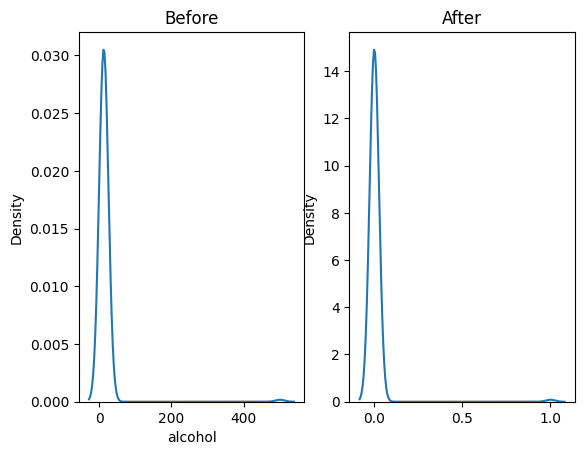

In [106]:
# Your code here: add outlier, apply MinMaxScaler, plot before vs after
df_wine_outlier = df_wine.copy()

# add artificial outlier
df_wine_outlier.loc[0, 'alcohol'] = 500

mms = MinMaxScaler()
scaled_wine = mms.fit_transform(df_wine_outlier[['alcohol']]).ravel()

fig, axes = plt.subplots(1, 2)
sns.kdeplot(df_wine_outlier['alcohol'], ax = axes[0]).set_title('Before')
sns.kdeplot(scaled_wine, ax = axes[1]).set_title('After')
plt.show()

#Ans: The values are distributed mostly in the area of 0 and an extreme outlier, right tail is spotted to 500.

### Problem 11
একই outlier-যুক্ত Wine data-তে এবার StandardScaler apply করো।
MinMaxScaler vs StandardScaler — কোনটা outlier-এ বেশি ক্ষতিগ্রস্ত হয়েছে?
দুটির output plot করে তুলনা করো।

In [ ]:
# Your code here: compare MinMaxScaler vs StandardScaler with outlier present


---
# Part 4: Robust Scaler
**Dataset: California Housing**

### Problem 12
California Housing dataset-এ 'AveRooms' column-এ RobustScaler apply করো।
Scaled data-র median এবং IQR print করো।
Expected: median ≈ 0।

In [ ]:
# Your code here: RobustScaler on AveRooms, check median and IQR


### Problem 13
RobustScaler manually implement করো।
formula: x_scaled = (x - median) / IQR
California Housing-এর 'AveOccup' column-এ apply করো এবং sklearn output-এর সাথে মিলিয়ে দেখো।

In [ ]:
# Your code here: manual RobustScaler and compare with sklearn


### Problem 14
California Housing-এর 'AveRooms' column-এ তিনটি scaler একসাথে compare করো:
StandardScaler, MinMaxScaler, RobustScaler।
তিনটির output এর KDE plot পাশাপাশি (3 subplots) দেখাও।
কোনটা outlier-এ সবচেয়ে কম প্রভাবিত হয়েছে?

In [ ]:
# Your code here: compare all 3 scalers side by side with KDE plots


### Problem 15
Data leakage experiment করো:
- Case A: Scaler শুধু train data-তে fit করো, test-এ transform করো।
- Case B: Scaler পুরো dataset-এ fit করো, তারপর split করো।

Diabetes dataset ব্যবহার করো। দুই case-এ test set-এর mean এবং std print করো।
পার্থক্য দেখাও এবং কোনটা সঠিক তা explain করো।

In [ ]:
# Your code here: demonstrate data leakage vs correct approach


---
# Part 5: ColumnTransformer
**Dataset: California Housing**

### Problem 16
California Housing dataset-এ নিচের transformation apply করো ColumnTransformer দিয়ে:
- 'MedInc', 'AveRooms' → StandardScaler
- 'Latitude', 'Longitude' → MinMaxScaler
- বাকি সব columns → passthrough (কোনো change নেই)

Train-test split করে শুধু train-এ fit করো।

In [ ]:
# Your code here: ColumnTransformer with mixed scaling


### Problem 17
Problem 16-এর ColumnTransformer-এ RobustScaler যোগ করো:
- 'AveOccup', 'AveBedrms' → RobustScaler

এখন তিনটি scaler একই pipeline-এ আছে।
Output DataFrame-এর shape এবং প্রথম 5 rows print করো।

In [ ]:
# Your code here: ColumnTransformer with all 3 scalers


### Problem 18
ColumnTransformer-এর `remainder='drop'` এবং `remainder='passthrough'` এর পার্থক্য কী?
California Housing dataset-এ দুটি case try করো এবং output shape তুলনা করো।

In [ ]:
# Your code here: compare remainder='drop' vs remainder='passthrough'


### Problem 19
Wine dataset-এ সব numeric features-এ StandardScaler apply করো ColumnTransformer দিয়ে।
এরপর `set_output(transform='pandas')` ব্যবহার করে output-কে DataFrame হিসেবে রাখো।
Column names ঠিক আছে কিনা verify করো।

In [ ]:
# Your code here: ColumnTransformer with set_output pandas


---
# Part 6: End-to-End Challenge Problems
এই problems-গুলো সব concepts একসাথে ব্যবহার করে।

### Problem 20 ⭐
Breast Cancer dataset নিয়ে পুরো preprocessing pipeline তৈরি করো:
1. Train-test split (80-20)
2. তিনটি scaler আলাদা আলাদাভাবে apply করো
3. প্রতিটি scaler-এর পর mean এবং std print করো
4. কোন scaler-এর output সবচেয়ে stable সেটা বলো

শুধু train-এ fit করতে ভুলো না।

In [ ]:
# Your code here: full pipeline with all 3 scalers


### Problem 21 ⭐
California Housing dataset-এ outlier detection করো:
1. 'AveOccup' column-এর boxplot দেখাও
2. IQR method দিয়ে outlier চিহ্নিত করো
3. Outlier সরানোর আগে এবং পরে StandardScaler apply করো
4. দুই ক্ষেত্রে scaled data-র describe() তুলনা করো

In [ ]:
# Your code here: outlier detection and scaling comparison


### Problem 22 ⭐
নিচের scenario-তে কোন scaler ব্যবহার করবে এবং কেন — code দিয়ে prove করো:

- Scenario A: Diabetes dataset-এর 'bmi' — normally distributed, কোনো extreme outlier নেই
- Scenario B: California Housing-এর 'AveOccup' — heavily skewed, extreme outliers আছে
- Scenario C: Wine dataset-এর 'alcohol' — neural network-এ input দেওয়া হবে

প্রতিটিতে correct scaler apply করো এবং output plot করো।

In [ ]:
# Your code here: choose correct scaler for each scenario


### Problem 23 ⭐
California Housing dataset-এ একটি complete ColumnTransformer pipeline তৈরি করো:
- 'MedInc' → StandardScaler (normally distributed income)
- 'Latitude', 'Longitude' → MinMaxScaler (geographic coordinates for neural net)
- 'AveOccup', 'AveRooms' → RobustScaler (skewed with outliers)
- বাকি columns → passthrough

Train-test split করে properly fit ও transform করো।
Final X_train এবং X_test shape print করো।

In [ ]:
# Your code here: complete ColumnTransformer pipeline


### Problem 24 ⭐
Scaler-এর inverse_transform কী কাজ করে?
Wine dataset-এ StandardScaler apply করো।
এরপর inverse_transform দিয়ে original values ফিরিয়ে আনো।
Original এবং recovered values কি same? Verify করো।

In [ ]:
# Your code here: apply StandardScaler and then inverse_transform


### Problem 25 ⭐
Final challenge: Data leakage এর real impact দেখাও।

Diabetes dataset-এ:
- Case A (Correct): train-এ fit, test-এ transform
- Case B (Wrong): full data-তে fit, তারপর split

দুই case-এ test set-এর scaled values-এর mean ও std compare করো।
পার্থক্য কতটুকু? Real-world-এ এই পার্থক্য কেন সমস্যা তৈরি করে সেটা comment-এ লেখো।

In [ ]:
# Your code here: demonstrate real impact of data leakage
